In [1]:
import pandas as pd
import numpy as np
from joblib import load
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# --- 1. Load Isolation Forest model, scaler, and datasets ---
try:
    scaler = load('/content/drive/MyDrive/Landslide project/Isolation forest/iso_scaler_before.joblib')
    iso_model = load('/content/drive/MyDrive/Landslide project/Isolation forest/iso_model_before.joblib')
    print("Isolation Forest model and scaler loaded successfully.")
except FileNotFoundError:
    print("Error: Model or scaler files not found. Make sure 'iso_scaler.joblib' and 'iso_model.joblib' are in the './model/' directory.")
    exit()

Isolation Forest model and scaler loaded successfully.


In [3]:
df_val=pd.read_csv("/content/drive/MyDrive/Landslide project/devID_109_label_data.csv")

In [4]:
# --- 2. Data Preprocessing ---
# Replace NaN values in the 'label' column with 'Normal'
df_val['label'] = df_val['label'].fillna('Normal')
print("\nMissing values in 'label' column replaced with 'Normal'.")

print("\nDataFrame Description after initial preprocessing:")
print(df_val.describe())
print("\nValue counts of 'label' column (after NaN handling):")
print(df_val['label'].value_counts())

# Define features for anomaly detection
feature_cols = ['soil','rain','temp','humi','geo']
if not all(col in df_val.columns for col in feature_cols):
    missing_cols = [col for col in feature_cols if col not in df_val.columns]
    print(f"Error: Missing feature columns in DataFrame: {missing_cols}")
    print("Please check your CSV files and 'feature_cols' definition.")
    exit()

X_val = df_val[feature_cols].values

# Scale the data using the pre-trained scaler
X_val_scaled = scaler.transform(X_val)
print(f"\nData scaled using {type(scaler).__name__}.")


Missing values in 'label' column replaced with 'Normal'.

DataFrame Description after initial preprocessing:
               soil          rain          temp          humi           geo  \
count  10756.000000  10756.000000  10756.000000  10756.000000  10756.000000   
mean      29.905815      0.215096     27.172087     84.222192      3.636631   
std        4.659946      1.905348      3.969878     12.822752      6.640261   
min       24.550000      0.000000     21.900000     44.099998    -65.452805   
25%       26.600000      0.000000     23.799999     73.599998      0.383324   
50%       26.900000      0.000000     25.600000     90.000000      0.573813   
75%       34.299999      0.000000     30.700001     94.800003      3.728545   
max       44.299999     33.947100     38.099998     98.300003     36.713737   

           iso_risk     lstm_risk            rf  
count  10756.000000  10756.000000  10756.000000  
mean       0.039048      0.017943      0.128765  
std        0.246142      0.1

In [5]:
# --- 3. Calculate Anomaly Scores and Classify Risk ---
df_val['anomaly_score'] = iso_model.decision_function(X_val_scaled)
print("Anomaly scores calculated.")

# Determine dynamic thresholds
#crit_thresh = -0.094870
#warn_thresh = -0.042534
crit_thresh = -0.1152
warn_thresh = -0.0289

print(f"\nDynamic Anomaly Score Thresholds:")
print(f"  Critical Threshold (0.5th percentile): {crit_thresh:.4f}")
print(f"  Warning Threshold (5th percentile): {warn_thresh:.4f}")

def classify_risk(score):
    if score < crit_thresh:
        return "Critical"
    elif score < warn_thresh:
        return "Warning"
    else:
        return "Normal"

df_val['predicted_risk'] = df_val['anomaly_score'].apply(classify_risk)
print("Risk levels ('Critical', 'Warning', 'Normal') assigned based on anomaly scores.")

print("\nPredicted Risk Distribution:")
print(df_val['predicted_risk'].value_counts())

print("\nLabel Distribution:")
print(df_val['label'].value_counts())

Anomaly scores calculated.

Dynamic Anomaly Score Thresholds:
  Critical Threshold (0.5th percentile): -0.1152
  Warning Threshold (5th percentile): -0.0289
Risk levels ('Critical', 'Warning', 'Normal') assigned based on anomaly scores.

Predicted Risk Distribution:
predicted_risk
Normal      10253
Warning       442
Critical       61
Name: count, dtype: int64

Label Distribution:
label
Normal      10574
warning       101
critical       81
Name: count, dtype: int64


In [6]:
# --- 4. Prepare True Labels for Multi-Class Evaluation ---

df_val['true_label_mapped_multi'] = df_val['label'].replace({
    'critical': 'Critical',
    'normal': 'Normal',
    'Normal': 'Normal',
    'warning':'Warning'
})

label_order = ['Critical', 'Warning', 'Normal']

df_val_filtered_multi_eval = df_val[df_val['true_label_mapped_multi'].isin(label_order)].copy()

y_true_multi = df_val_filtered_multi_eval['true_label_mapped_multi']
y_pred_multi = df_val_filtered_multi_eval['predicted_risk']

print("\nTrue Label Mapping for Multi-Class Evaluation:")
print(y_true_multi.value_counts())
print("\nPredicted Risk Label Distribution (for Multi-Class F1-score):")
print(y_pred_multi.value_counts())


True Label Mapping for Multi-Class Evaluation:
true_label_mapped_multi
Normal      10574
Warning       101
Critical       81
Name: count, dtype: int64

Predicted Risk Label Distribution (for Multi-Class F1-score):
predicted_risk
Normal      10253
Warning       442
Critical       61
Name: count, dtype: int64


In [7]:
# --- 5. Calculate and Print Multi-Class F1-score and other metrics ---
print("\n--- Multi-Class Model Evaluation (Normal, Warning, Critical) ---")

# For multi-class F1-score, we usually use 'weighted' or 'macro' average
# 'weighted' accounts for class imbalance
# 'macro' treats all classes equally
# 'None' gives F1-score for each class separately
f1_weighted = f1_score(y_true_multi, y_pred_multi, average='weighted', labels=label_order, zero_division=0)
f1_macro = f1_score(y_true_multi, y_pred_multi, average='macro', labels=label_order, zero_division=0)
f1_per_class = f1_score(y_true_multi, y_pred_multi, average=None, labels=label_order, zero_division=0)

print(f"\nWeighted F1-score: {f1_weighted:.4f}")
print(f"Macro F1-score: {f1_macro:.4f}")
print(f"F1-score per class ({label_order}): {f1_per_class}")


# Full classification report for multi-class
print("\nClassification Report (Multi-Class):")
# target_names should match the order of labels in y_true_multi and y_pred_multi
print(classification_report(y_true_multi, y_pred_multi, labels=label_order, target_names=label_order, zero_division=0))


# Confusion Matrix for multi-class
cm_multi = confusion_matrix(y_true_multi, y_pred_multi, labels=label_order)
print("\nConfusion Matrix (Multi-Class):")
print(cm_multi)


--- Multi-Class Model Evaluation (Normal, Warning, Critical) ---

Weighted F1-score: 0.9759
Macro F1-score: 0.7104
F1-score per class (['Critical', 'Warning', 'Normal']): [0.83098592 0.31675875 0.98333894]

Classification Report (Multi-Class):
              precision    recall  f1-score   support

    Critical       0.97      0.73      0.83        81
     Warning       0.19      0.85      0.32       101
      Normal       1.00      0.97      0.98     10574

    accuracy                           0.97     10756
   macro avg       0.72      0.85      0.71     10756
weighted avg       0.99      0.97      0.98     10756


Confusion Matrix (Multi-Class):
[[   59    22     0]
 [    2    86    13]
 [    0   334 10240]]


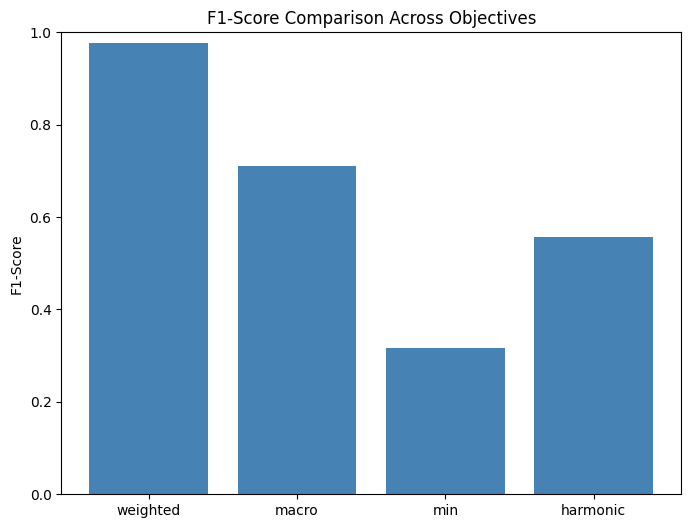

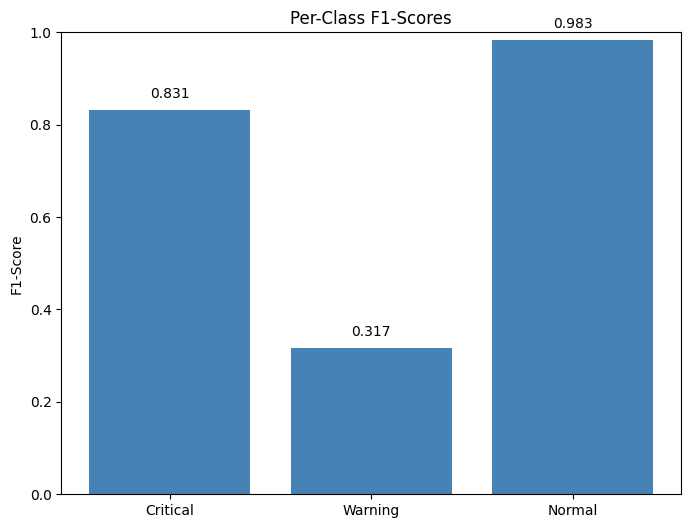

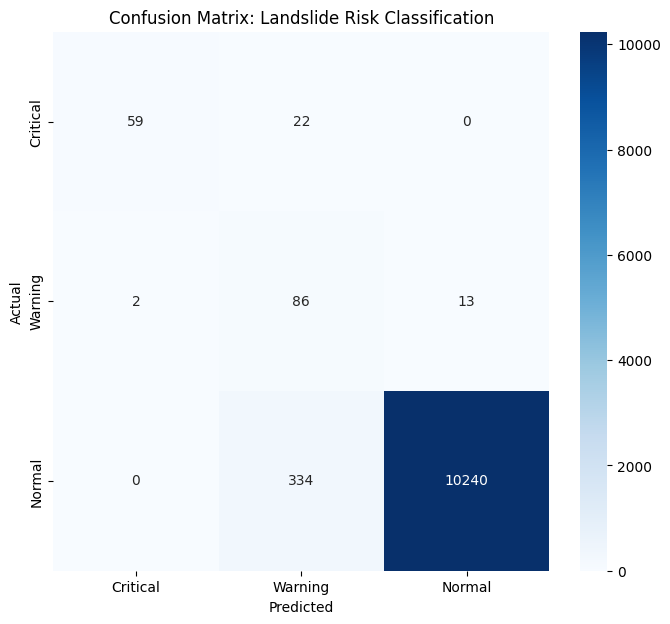

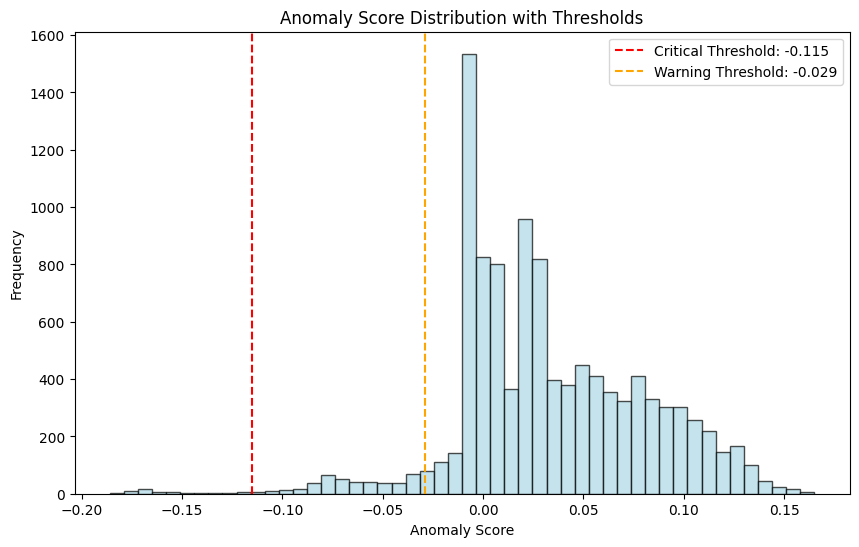

In [8]:
# --- Visualization (Separate Plots) ---

# Plot 1: F1-score comparison (Weighted, Macro, Min, Harmonic)
plt.figure(figsize=(8, 6))
objectives_plot = ['weighted', 'macro', 'min', 'harmonic']
scores = [
    f1_weighted,          # weighted
    f1_macro,             # macro
    min(f1_per_class),    # min
    (len(f1_per_class) / np.sum(1.0 / (f1_per_class + 1e-8)))  # harmonic mean
]
plt.bar(objectives_plot, scores, color='steelblue')
plt.title('F1-Score Comparison Across Objectives')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.show()

# Plot 2: Per-class F1-scores
plt.figure(figsize=(8, 6))
plt.bar(label_order, f1_per_class, color='steelblue')
plt.title('Per-Class F1-Scores')
plt.ylabel('F1-Score')
plt.ylim(0, 1)

# Add value labels on bars
for i, v in enumerate(f1_per_class):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')
plt.show()

# Plot 3: Confusion Matrix Heatmap
plt.figure(figsize=(8, 7))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_order, yticklabels=label_order)
plt.title('Confusion Matrix: Landslide Risk Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot 4: Anomaly Score Distribution with thresholds
plt.figure(figsize=(10, 6))
plt.hist(df_val['anomaly_score'], bins=50, alpha=0.7,
         color='lightblue', edgecolor='black')
plt.axvline(crit_thresh, color='red', linestyle='--',
            label=f'Critical Threshold: {crit_thresh:.3f}')
plt.axvline(warn_thresh, color='orange', linestyle='--',
            label=f'Warning Threshold: {warn_thresh:.3f}')
plt.title('Anomaly Score Distribution with Thresholds')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()